<a href="https://colab.research.google.com/github/Prerna-Karle/GenAI-Foundational-Models/blob/main/GAIFM_Practical02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

# Step 1: Import libraries
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.3 MB/s eta 0:00:00


In [2]:
# Step 2: Create a small corpus
sentences = [
    ['king', 'queen', 'prince', 'princess'],
    ['man', 'woman', 'boy', 'girl'],
    ['dog', 'cat', 'animal', 'pet'],
    ['apple', 'banana', 'mango', 'fruit'],
    ['car', 'bus', 'train', 'vehicle'],
    ['king', 'man', 'queen', 'woman'],
    ['dog', 'cat', 'pet'],
    ['apple', 'fruit', 'banana']
]

In [3]:
# Step 3: Train Word2Vec model
model = Word2Vec(
    sentences,
    vector_size=20,
    window=2,
    min_count=1,
    workers=1
)

In [4]:
# Step 4: Get word vectors
king_vector = model.wv['king']
queen_vector = model.wv['queen']
dog_vector = model.wv['dog']


king_vector

array([-0.0468503 ,  0.0191337 ,  0.0244224 , -0.03214282,  0.00604279,
       -0.01037438,  0.00012202, -0.04941754,  0.01346002, -0.02375053,
        0.00543823, -0.00788112,  0.01098337, -0.03940788, -0.01358592,
        0.01331599,  0.02673341, -0.01195757, -0.04755047,  0.02252939],
      dtype=float32)

In [5]:
# Step 5: Calculate cosine similarity
similarity1 = cosine_similarity(
    [king_vector],
    [queen_vector]
)

similarity2 = cosine_similarity(
    [king_vector],
    [dog_vector]
)

print("Similarity between King and Queen:",
      similarity1[0][0])

print("Similarity between King and Dog:",
      similarity2[0][0])

Similarity between King and Queen: -0.0024610823
Similarity between King and Dog: 0.12416858


In [6]:
# Step 6: Prepare words for visualization
words = list(model.wv.index_to_key)

words

['fruit',
 'banana',
 'apple',
 'pet',
 'cat',
 'dog',
 'woman',
 'man',
 'queen',
 'king',
 'vehicle',
 'train',
 'bus',
 'car',
 'mango',
 'animal',
 'girl',
 'boy',
 'princess',
 'prince']

In [7]:
# Step 7: Get embeddings
word_vectors = model.wv[words]

In [8]:
# Step 8: Reduce dimensions using PCA
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

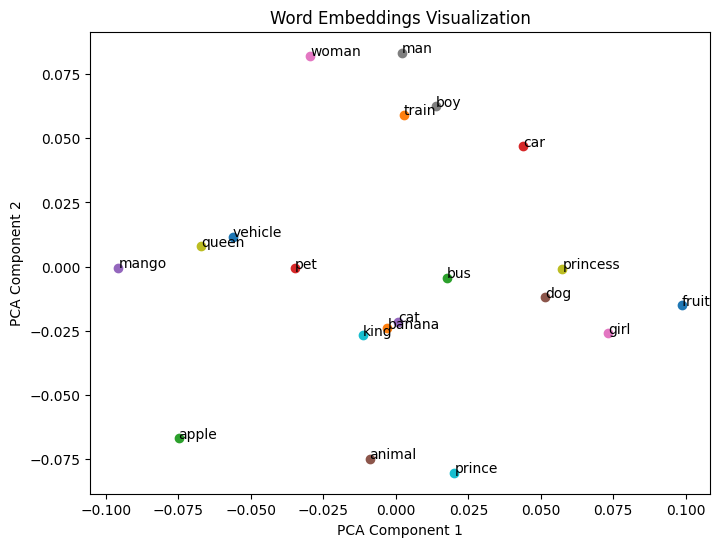

In [9]:
# Step 9: Plot embeddings
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1])
    plt.text(result[i,0], result[i,1], word)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [10]:
model.wv.most_similar('king', topn=5)

[('animal', 0.49266865849494934),
 ('bus', 0.26634466648101807),
 ('girl', 0.19323821365833282),
 ('prince', 0.181691974401474),
 ('dog', 0.12416858971118927)]

# Practice Purpose

In [11]:
!pip install gensim

# Step 1: Import libraries
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [12]:
# Step 2: Create a small corpus
sentences = [
    ['football', 'soccer', 'basketball', 'sport'],
    ['player', 'coach', 'referee', 'team'],
    ['india', 'china', 'japan', 'country'],
    ['delhi', 'beijing', 'tokyo', 'city'],
    ['cricket', 'bat', 'ball', 'wicket'],
    ['football', 'player', 'basketball', 'coach'],
    ['india', 'delhi', 'country'],
    ['cricket', 'sport', 'bat']
]

In [13]:
# Step 3: Train Word2Vec model
model = Word2Vec(
    sentences,
    vector_size=20,
    window=2,
    min_count=1,
    workers=1
)


In [14]:
# Step 4: Get word vectors
football_vector = model.wv['football']
cricket_vector = model.wv['cricket']
india_vector = model.wv['india']
football_vector

array([-0.0468503 ,  0.0191337 ,  0.0244224 , -0.03214282,  0.00604279,
       -0.01037438,  0.00012202, -0.04941754,  0.01346002, -0.02375053,
        0.00543823, -0.00788112,  0.01098337, -0.03940788, -0.01358592,
        0.01331599,  0.02673341, -0.01195757, -0.04755047,  0.02252939],
      dtype=float32)

In [15]:
# Step 5: Calculate cosine similarity
similarity1 = cosine_similarity(
    [football_vector],
    [cricket_vector]
)
similarity2 = cosine_similarity(
    [football_vector],
    [india_vector]
)
print("Similarity between Football and Cricket:",
      similarity1[0][0])
print("Similarity between Football and India:",
      similarity2[0][0])

Similarity between Football and Cricket: 0.076453544
Similarity between Football and India: -0.036905866


In [16]:
# Step 6: Prepare words for visualization
words = list(model.wv.index_to_key)
words

['bat',
 'cricket',
 'delhi',
 'country',
 'india',
 'coach',
 'player',
 'sport',
 'basketball',
 'football',
 'wicket',
 'ball',
 'city',
 'tokyo',
 'beijing',
 'japan',
 'china',
 'team',
 'referee',
 'soccer']

In [17]:
# Step 7: Get embeddings
word_vectors = model.wv[words]

In [18]:
# Step 8: Reduce dimensions using PCA
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

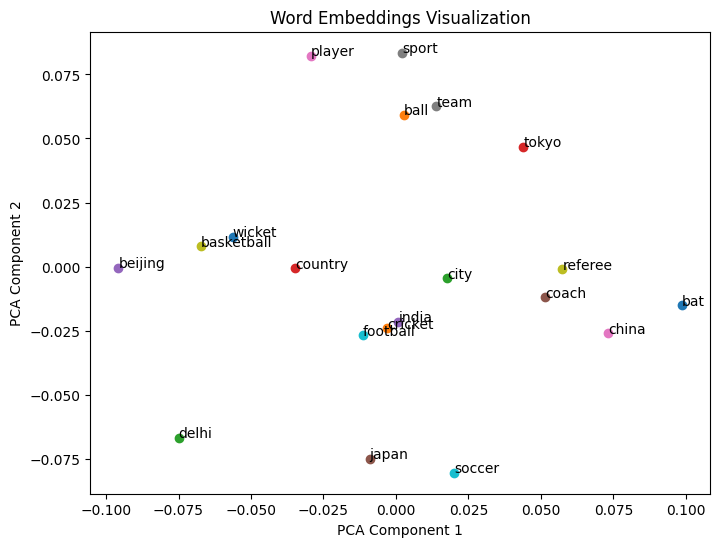

[('japan', 0.49266865849494934),
 ('city', 0.2663307785987854),
 ('china', 0.19323821365833282),
 ('soccer', 0.18172109127044678),
 ('coach', 0.12416858971118927)]

In [19]:
# Step 9: Plot embeddings
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1])
    plt.text(result[i,0], result[i,1], word)
plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

model.wv.most_similar('football', topn=5)